In [0]:

folder_path = "/Volumes/workspace/default/my_project_data1/"

df = spark.read.parquet(folder_path)

df.show(5)


+--------------------+----------+----------+-------------------+--------------------+--------+-------+---------+--------------------+
|          event_time|event_type|product_id|        category_id|       category_code|   brand|  price|  user_id|        user_session|
+--------------------+----------+----------+-------------------+--------------------+--------+-------+---------+--------------------+
|2019-10-01 00:00:...|      view|  44600062|2103807459595387724|                NULL|shiseido|  35.79|541312140|72d76fde-8bb3-4e0...|
|2019-10-01 00:00:...|      view|   3900821|2053013552326770905|appliances.enviro...|    aqua|   33.2|554748717|9333dfbd-b87a-470...|
|2019-10-01 00:00:...|      view|  17200506|2053013559792632471|furniture.living_...|    NULL|  543.1|519107250|566511c2-e2e3-422...|
|2019-10-01 00:00:...|      view|   1307067|2053013558920217191|  computers.notebook|  lenovo| 251.74|550050854|7c90fc70-0e80-459...|
|2019-10-01 00:00:...|      view|   1004237|205301355563188265

In [0]:
df.filter(df['price']<10).show(5)

+--------------------+----------+----------+-------------------+-------------+---------+-----+---------+--------------------+
|          event_time|event_type|product_id|        category_id|category_code|    brand|price|  user_id|        user_session|
+--------------------+----------+----------+-------------------+-------------+---------+-----+---------+--------------------+
|2019-10-01 00:06:...|      view|  12800417|2053013552788144369|         NULL| kingston| 5.12|555373493|fbf1cb86-e2c4-453...|
|2019-10-01 00:07:...|      view|  15300165|2053013552662315243|         NULL|transcend| 6.12|553079594|ded71961-1c04-4d4...|
|2019-10-01 00:09:...|      view|  26010220|2053013562611204913|         NULL|     NULL| 2.17|551748159|7a1f9af2-07e7-49f...|
|2019-10-01 00:10:...|      view|  24100257|2053013563307459413|         NULL|     NULL| 2.86|512637377|9cc0d7ba-50d3-4f5...|
|2019-10-01 00:10:...|      view|  24100265|2053013563307459413|         NULL|     NULL| 2.86|512637377|9cc0d7ba-50d3-

In [0]:
from pyspark.sql.functions import col, sum

# For all columns
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+
|event_time|event_type|product_id|category_id|category_code|  brand|price|user_id|user_session|
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+
|         0|         0|         0|          0|      6558271|2836723|    0|      0|           1|
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+



In [0]:
df.printSchema()

root
 |-- event_time: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: long (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: long (nullable = true)
 |-- user_session: string (nullable = true)



In [0]:
df.filter(col("category_code").isNull()).count()

6558271

In [0]:
from pyspark.sql.functions import *

mode_category_code = (
    df.filter(col("category_code").isNotNull())
      .groupBy("category_code")
      .count()
      .orderBy(desc("count"))
      .first()[0]
)
df = df.fillna({"category_code": mode_category_code})


In [0]:
from pyspark.sql.functions import *

mode_brand = (
    df.filter(col("brand").isNotNull())
      .groupBy("brand")
      .count()
      .orderBy(desc("count"))
      .first()[0]
)
df = df.fillna({"brand": mode_brand})


In [0]:
df.filter(col("category_code").isNull()).count()

0

In [0]:
df.filter(col("brand").isNull()).count()

0

In [0]:
df = df.na.drop(subset=["user_session"])

In [0]:
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])

DataFrame[event_time: bigint, event_type: bigint, product_id: bigint, category_id: bigint, category_code: bigint, brand: bigint, price: bigint, user_id: bigint, user_session: bigint]

In [0]:
from pyspark.sql.functions import to_timestamp

df = df.withColumn("event_time", to_timestamp("event_time"))

In [0]:
from pyspark.sql.functions import hour, dayofweek, month

df = df.withColumn("hour", hour("event_time"))
df = df.withColumn("day_of_week", dayofweek("event_time"))
df = df.withColumn("month", month("event_time"))

In [0]:
df.printSchema()

root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: long (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = false)
 |-- brand: string (nullable = false)
 |-- price: double (nullable = true)
 |-- user_id: long (nullable = true)
 |-- user_session: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- month: integer (nullable = true)



In [0]:
df.show(2)

+-------------------+----------+----------+-------------------+--------------------+--------+-----+---------+--------------------+----+-----------+-----+
|         event_time|event_type|product_id|        category_id|       category_code|   brand|price|  user_id|        user_session|hour|day_of_week|month|
+-------------------+----------+----------+-------------------+--------------------+--------+-----+---------+--------------------+----+-----------+-----+
|2019-10-01 00:00:00|      view|  44600062|2103807459595387724|electronics.smart...|shiseido|35.79|541312140|72d76fde-8bb3-4e0...|   0|          3|   10|
|2019-10-01 00:00:00|      view|   3900821|2053013552326770905|appliances.enviro...|    aqua| 33.2|554748717|9333dfbd-b87a-470...|   0|          3|   10|
+-------------------+----------+----------+-------------------+--------------------+--------+-----+---------+--------------------+----+-----------+-----+
only showing top 2 rows


In [0]:
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()   

+----------+----------+----------+-----------+-------------+-----+-----+-------+------------+----+-----------+-----+
|event_time|event_type|product_id|category_id|category_code|brand|price|user_id|user_session|hour|day_of_week|month|
+----------+----------+----------+-----------+-------------+-----+-----+-------+------------+----+-----------+-----+
|         0|         0|         0|          0|            0|    0|    0|      0|           0|   0|          0|    0|
+----------+----------+----------+-----------+-------------+-----+-----+-------+------------+----+-----------+-----+



In [0]:
df.count()

19999999

In [0]:
df = df.dropDuplicates()

In [0]:
df.count()

19987398

In [0]:
df.createOrReplaceTempView("events")

In [0]:
features_df = spark.sql("""
SELECT user_id, COUNT(*) AS total_events
FROM events
GROUP BY user_id
""")


In [0]:
top_cutomer=spark.sql('''select user_id,brand,sum(price) as spend from events group by user_id,brand order by count(*) desc''')


In [0]:
top_month=spark.sql('''select month,sum(price) from events group by month order by sum(price) desc''')


In [0]:
spark.sql('''select day_of_week,sum(price) from events group by day_of_week order by sum(price) desc''').show(5)


+-----------+--------------------+
|day_of_week|          sum(price)|
+-----------+--------------------+
|          3|1.0741464787000787E9|
|          1| 8.546315448900836E8|
|          6| 8.448690196599901E8|
|          7|  8.12339179780015E8|
|          2| 7.884386068700973E8|
+-----------+--------------------+
only showing top 5 rows


In [0]:
spark.sql('''select category_code,count(*) as view_count from events where event_type='view' group by category_code order by count(*) desc''')

DataFrame[category_code: string, view_count: bigint]

In [0]:
total_spent=spark.sql('''SELECT
user_id,
SUM(price) AS total_spent
FROM events
WHERE event_type = 'purchase'
GROUP BY user_id''')


In [0]:
avg_purchase_price=spark.sql('''SELECT
user_id,
AVG(price) AS avg_purchase_price
FROM events
WHERE event_type = 'purchase'
GROUP BY user_id''')


In [0]:
recency = spark.sql("""
SELECT
    user_id,
    datediff(max_date, max(event_time)) AS recency_days
FROM events
CROSS JOIN (
    SELECT max(event_time) AS max_date FROM events
) t
GROUP BY user_id, max_date
""")


In [0]:
product_diversity=spark.sql('''SELECT
user_id,
COUNT(DISTINCT product_id) AS product_diversity
FROM events
WHERE event_type = 'purchase'
GROUP BY user_id''')


In [0]:
category_diversity=spark.sql('''SELECT
user_id,
COUNT(DISTINCT category_id) AS category_diversity
FROM events
GROUP BY user_id''')


In [0]:
purchase_ratio=spark.sql('''SELECT
user_id,
SUM(CASE WHEN event_type='view' THEN 1 ELSE 0 END) AS views,
SUM(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) AS purchases
FROM events
GROUP BY user_id''')


In [0]:
session_count=spark.sql('''SELECT
user_id,
COUNT(DISTINCT user_session) AS session_count
FROM events
GROUP BY user_id''')


In [0]:
avg_purchase_price.createOrReplaceTempView("avg_price_table")
recency.createOrReplaceTempView("recency_table")
total_spent.createOrReplaceTempView("total_spent_table")
product_diversity.createOrReplaceTempView("product_diversity_table")
category_diversity.createOrReplaceTempView("category_diversity_table")
purchase_ratio.createOrReplaceTempView("purchase_ratio_table")
session_count.createOrReplaceTempView("session_count_table")

In [0]:
final_table = spark.sql("""
SELECT
    a.user_id,
    b.total_spent,
    c.avg_purchase_price,
    d.recency_days,
    e.product_diversity,
    f.category_diversity,
    g.purchases,
    h.session_count
FROM avg_price_table a
LEFT JOIN total_spent_table b
    ON a.user_id = b.user_id
LEFT JOIN avg_price_table c
    ON a.user_id = c.user_id
LEFT JOIN recency_table d
    ON a.user_id = d.user_id
LEFT JOIN product_diversity_table e
    ON a.user_id = e.user_id
LEFT JOIN category_diversity_table f
    ON a.user_id = f.user_id
LEFT JOIN purchase_ratio_table g
    ON a.user_id = g.user_id
LEFT JOIN session_count_table h
    ON a.user_id = h.user_id
""")

In [0]:
from pyspark.sql.functions import percentile_approx

threshold = final_table.select(
    percentile_approx("recency_days", 0.75)
).collect()[0][0]

print("Threshold:", threshold)

Threshold: 8


In [0]:
from pyspark.sql.functions import when

final_table = final_table.withColumn(
    "churn",
    when(final_table.recency_days > threshold, 1).otherwise(0)
)

In [0]:
final_table.createOrReplaceTempView("final_table")

In [0]:
final_table.show(5)

+---------+------------------+------------------+------------+-----------------+------------------+---------+-------------+-----+
|  user_id|       total_spent|avg_purchase_price|recency_days|product_diversity|category_diversity|purchases|session_count|churn|
+---------+------------------+------------------+------------+-----------------+------------------+---------+-------------+-----+
|556446324|            244.21|           122.105|           6|                2|                 2|        2|            8|    0|
|533158264|           6207.42|           620.742|           0|                6|                 7|       10|           12|    0|
|513923621|1214.4299999999998|134.93666666666664|           0|                4|                 5|        9|           15|    0|
|522884414|336.95000000000005| 67.39000000000001|           4|                3|                 2|        5|            4|    0|
|551558123|             804.4|134.06666666666666|           2|                5|          

In [0]:
df = spark.sql("SELECT * FROM final_table")

In [0]:
pdf = df.toPandas()

In [0]:
pdf.to_csv("/tmp/final_table.csv", index=False)

In [0]:
import mlflow

with mlflow.start_run():
    mlflow.log_artifact("/tmp/final_table.csv")

In [0]:
df.write.mode("overwrite").parquet("/tmp/final_table_parquet")

{"ts": "2026-03-19 13:46:24.999", "level": "ERROR", "logger": "pyspark.sql.connect.logging", "msg": "GRPC Error received", "context": {}, "exception": {"class": "_MultiThreadedRendezvous", "msg": "<_MultiThreadedRendezvous of RPC that terminated with:\n\tstatus = StatusCode.INTERNAL\n\tdetails = \"[DBFS_DISABLED] Public DBFS root is disabled. Access is denied on path: /tmp/final_table_parquet/_delta_log SQLSTATE: 56038\"\n\tdebug_error_string = \"UNKNOWN:Error received from peer  {grpc_message:\"[DBFS_DISABLED] Public DBFS root is disabled. Access is denied on path: /tmp/final_table_parquet/_delta_log SQLSTATE: 56038\", grpc_status:13, created_time:\"2026-03-19T13:46:24.998793949+00:00\"}\"\n>", "stacktrace": [{"class": null, "method": "_execute_and_fetch_as_iterator", "file": "/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py", "line": "2046"}, {"class": null, "method": "__next__", "file": "<frozen _collections_abc>", "line": "356"}, {"class": null, "m

---------------------------------------------------------------------------
UnsupportedOperationException             Traceback (most recent call last)
File <command-8145781298069789>, line 1
----> 1 df.write.mode("overwrite").parquet("/tmp/final_table_parquet")

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/readwriter.py:779, in DataFrameWriter.parquet(self, path, mode, partitionBy, compression)
    777     self.partitionBy(partitionBy)
    778 self._set_opts(compression=compression)
--> 779 self.format("parquet").save(path)

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/readwriter.py:703, in DataFrameWriter.save(self, path, format, mode, partitionBy, **options)
    701     self.format(format)
    702 self._write.path = path
--> 703 _, _, ei = self._spark.client.execute_command(
    704     self._write.command(self._spark.client), self._write.observations
    705 )
    706 self._callback(ei)

File /databricks/python/lib/python3.12/

In [0]:
final_table.groupBy("churn").count().show()

+-----+------+
|churn| count|
+-----+------+
|    0|146419|
|    1| 37916|
+-----+------+



In [0]:
final_table.count()

184335

In [0]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "purchases",
        "total_spent",
        "avg_purchase_price",
        "product_diversity",
        "category_diversity",
        "session_count",
    ],
    outputCol="features"
)

ml_data = assembler.transform(final_table)

In [0]:
ml_data.printSchema()
ml_data.select("features").show(5, False)

root
 |-- user_id: long (nullable = true)
 |-- total_spent: double (nullable = true)
 |-- avg_purchase_price: double (nullable = true)
 |-- recency_days: integer (nullable = true)
 |-- product_diversity: long (nullable = true)
 |-- category_diversity: long (nullable = true)
 |-- purchases: long (nullable = true)
 |-- session_count: long (nullable = true)
 |-- churn: integer (nullable = false)
 |-- features: vectorudt (nullable = true)

+--------------------------------------------------------+
|features                                                |
+--------------------------------------------------------+
|[2.0,244.21,122.105,2.0,2.0,8.0]                        |
|[10.0,6207.42,620.742,6.0,7.0,12.0]                     |
|[9.0,1214.4299999999998,134.93666666666664,4.0,5.0,15.0]|
|[5.0,336.95000000000005,67.39000000000001,3.0,2.0,4.0]  |
|[6.0,804.4,134.06666666666666,5.0,7.0,9.0]              |
+--------------------------------------------------------+
only showing top 5 rows


In [0]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(ml_data)
ml_data = scaler_model.transform(ml_data)

In [0]:
ml_data.select('scaled_features').show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------+
|scaled_features                                                                                                          |
+-------------------------------------------------------------------------------------------------------------------------+
|[0.03723337173821232,-0.20850757492126273,-0.4985499654214332,0.4309513254945665,-0.3448842713153479,0.43648196321437943]|
|[2.929832077612642,3.4558733213227644,1.0753609011307597,3.6884672701787564,0.7924863746529467,1.0964504464524423]       |
|[2.568257239378338,0.3876907198149413,-0.4580477571965278,2.0597092978366613,0.33753811626562885,1.5914268088809895]     |
|[1.1219578864411235,-0.1515190260830244,-0.671253822261987,1.245330311665614,-0.3448842713153479,-0.22348652002368335]   |
|[1.4835327246754269,0.13572808578277779,-0.4607938479477163,2.874088284007709,0.7924863746529467,0.6014740840238951]     |
+-------

In [0]:
train_df, test_df = ml_data.randomSplit([0.8, 0.2], seed=42)

In [0]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="scaled_features",  # USE SCALED
    labelCol="churn",
    numTrees=100,
    maxDepth=10
)

model = rf.fit(train_df)

In [0]:
prediction_ = model.transform(test_df)

prediction_.select(
    "user_id",
    "churn",
    "prediction",
    "probability"
).show(5)

+---------+-----+----------+--------------------+
|  user_id|churn|prediction|         probability|
+---------+-----+----------+--------------------+
|427391662|    0|       0.0|[0.96208204873267...|
|465832070|    0|       0.0|[0.75736367157854...|
|475293209|    1|       0.0|[0.53892247562107...|
|496542338|    0|       0.0|[0.78519501092935...|
|512363656|    0|       0.0|[0.97005994796927...|
+---------+-----+----------+--------------------+
only showing top 5 rows


In [0]:
rf_model = model

print(rf_model.getNumTrees)

100


In [0]:
import mlflow
import pickle

with mlflow.start_run():
    with open("/tmp/model.pkl", "wb") as f:
        pickle.dump(model, f)

    mlflow.log_artifact("/tmp/model.pkl")

---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
File <command-8145781298069783>, line 6
      4 with mlflow.start_run():
      5     with open("/tmp/model.pkl", "wb") as f:
----> 6         pickle.dump(model, f)
      8     mlflow.log_artifact("/tmp/model.pkl")

TypeError: cannot pickle '_thread.lock' object

In [0]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    labelCol="churn",
    featuresCol="features",
    maxIter=50
)

gbt_model = gbt.fit(train_df)

In [0]:

predictions_gbt_model = gbt_model.transform(test_df)

predictions.select(
    "user_id",
    "churn",
    "prediction",
    "probability"
).show(5)

+---------+-----+----------+--------------------+
|  user_id|churn|prediction|         probability|
+---------+-----+----------+--------------------+
|427391662|    0|       0.0|[0.96402535957523...|
|465832070|    0|       0.0|[0.75910793261963...|
|475293209|    1|       0.0|[0.51751183080808...|
|496542338|    0|       0.0|[0.78534622665117...|
|512363656|    0|       0.0|[0.97107877700010...|
+---------+-----+----------+--------------------+
only showing top 5 rows


In [0]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="churn",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(predictions)
print("AUC:", auc)

AUC: 0.7374965794620499


In [0]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="churn",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(predictions_gbt_model)
print("AUC:", auc)

AUC: 0.7410718828079687


In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

f1_eval = MulticlassClassificationEvaluator(
    labelCol="churn",
    metricName="f1"
)

print("F1 Score:", f1_eval.evaluate(predictions))

F1 Score: 0.7150910243276535


In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

f1_eval = MulticlassClassificationEvaluator(
    labelCol="churn",
    metricName="f1"
)

print("F1 Score:", f1_eval.evaluate(predictions_gbt_model))

F1 Score: 0.7169864334629072


In [0]:
'''from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[assembler, scaler, rf])

pipeline_model = pipeline.fit(train_df)

predictions = pipeline_model.transform(test_df)'''

'from pyspark.ml import Pipeline\n\npipeline = Pipeline(stages=[assembler, scaler, rf])\n\npipeline_model = pipeline.fit(train_df)\n\npredictions = pipeline_model.transform(test_df)'

K Means : MOdel 2


In [0]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.sql.functions import col, when

In [0]:
feature_cols = [
    "purchases",
    "total_spent",
    "avg_purchase_price",
    "product_diversity",
    "category_diversity",
    "session_count"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features2"
)

ml_data = assembler.transform(final_table)

In [0]:
kmeans = KMeans(
    featuresCol="features2",
    k=3,
    seed=42
)
k_model = kmeans.fit(ml_data)
clusters = k_model.transform(ml_data)

In [0]:
from pyspark.sql.functions import when, col

clusters_labeled = clusters.withColumn(
    "customer_segment",
    when(col("prediction") == 2, "High-Value")
    .when(col("prediction") == 0, "Regular")
    .when(col("prediction") == 1, "At-Risk")
)

In [0]:
clusters_labeled.groupBy("customer_segment").count().show()

+----------------+------+
|customer_segment| count|
+----------------+------+
|         Regular|177706|
|      High-Value|  6422|
|         At-Risk|   207|
+----------------+------+



In [0]:
clusters_labeled.groupBy("customer_segment").avg(
    "total_spent",
    "purchases",
    "avg_purchase_price",
    "product_diversity",
    "category_diversity",
    "session_count"
).show()

+----------------+-----------------+-----------------+-----------------------+----------------------+-----------------------+------------------+
|customer_segment| avg(total_spent)|   avg(purchases)|avg(avg_purchase_price)|avg(product_diversity)|avg(category_diversity)|avg(session_count)|
+----------------+-----------------+-----------------+-----------------------+----------------------+-----------------------+------------------+
|         Regular|395.7456089271032|1.632533510404826|     258.92784602207047|    1.3676409350275174|      3.482414774965392| 5.126866847489674|
|      High-Value|  4836.0793646839|8.087200249143569|       842.508144497211|     4.087511678604796|     4.3762067891622545| 10.81174089068826|
|         At-Risk|29855.85077294686|36.91304347826087|      965.5975020116019|     8.869565217391305|      5.792270531400966|31.492753623188406|
+----------------+-----------------+-----------------+-----------------------+----------------------+-----------------------+-----

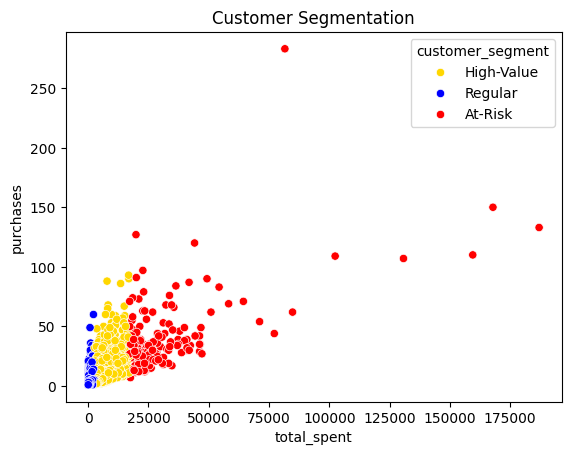

In [0]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pdf = clusters_labeled.select(
    "total_spent", "purchases", "session_count", "customer_segment"
).toPandas()

sns.scatterplot(
    data=pdf,
    x="total_spent",
    y="purchases",
    hue="customer_segment",
    palette=["gold", "blue", "red"]
)
plt.title("Customer Segmentation")
plt.show()

Model 3 Purchase Amount Prediction

In [0]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, GBTRegressor, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [0]:
feature_cols3 = [
    "purchases",
    "total_spent",
    "avg_purchase_price",
    "product_diversity",
    "category_diversity",
    "session_count",
    "recency_days"
]

In [0]:
assembler = VectorAssembler(
    inputCols=feature_cols3,
    outputCol="features3"
)

ml_data_reg = assembler.transform(final_table)

In [0]:
scaler = StandardScaler(
    inputCol="features3",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(ml_data_reg)
ml_data_scaled = scaler_model.transform(ml_data_reg)

---------------------------------------------------------------------------
SparkException                            Traceback (most recent call last)
File <command-5299995769569095>, line 8
      1 scaler = StandardScaler(
      2     inputCol="features3",
      3     outputCol="scaled_features",
      4     withMean=True,
      5     withStd=True
      6 )
----> 8 scaler_model = scaler.fit(ml_data_reg)
      9 ml_data_scaled = scaler_model.transform(ml_data_reg)

File /databricks/python_shell/lib/dbruntime/MLWorkloadsInstrumentation/_pyspark.py:30, in _create_patch_function.<locals>.patched_method(self, *args, **kwargs)
     28 call_succeeded = False
     29 try:
---> 30     result = original_method(self, *args, **kwargs)
     31     call_succeeded = True
     32     return result

File /databricks/python/lib/python3.12/site-packages/pyspark/ml/base.py:203, in Estimator.fit(self, dataset, params)
    201         return self.copy(params)._fit(dataset)
    202     else:
--> 203       